     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 2


Extracting Dataset Version Zip to Wild-Animals-1 in yolov8:: 100%|██████████| 19406/19406 [00:02<00:00, 8667.26it/s]



Trening: yolov8s_640
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Wild-Animals-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_640, nbs=64, nms=False, opset=None, optimize=False, optimizer=

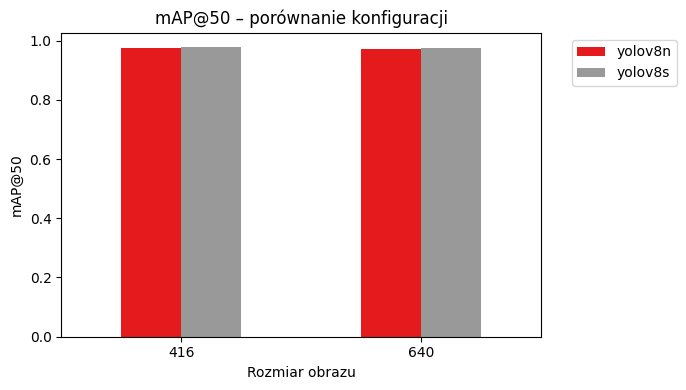

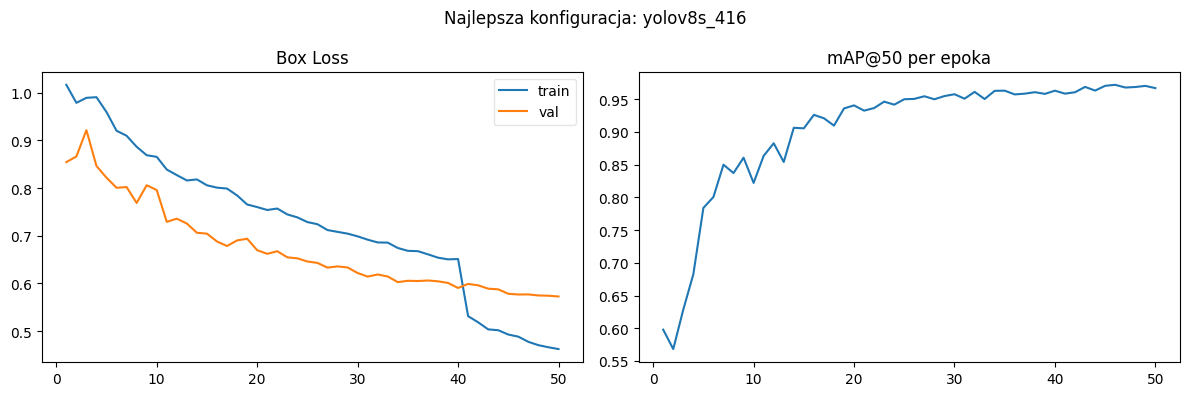

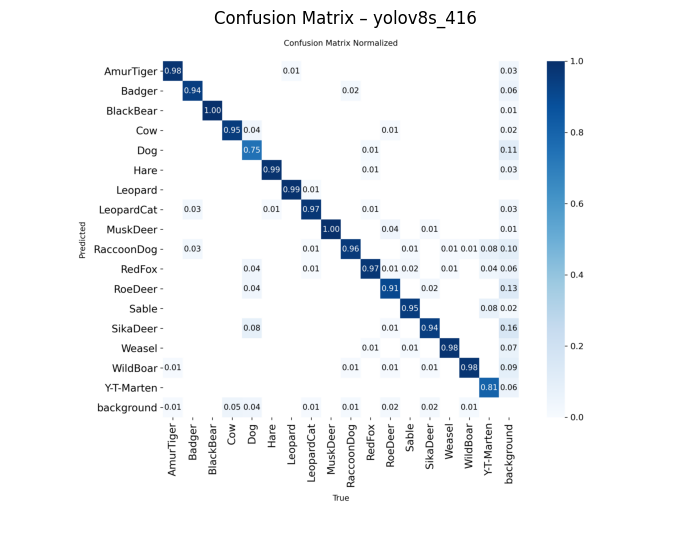


✓ Wszystko zapisane w /kaggle/working/yolo_runs/


In [ ]:
# INSTALACJA
!pip install ultralytics roboflow -q

import os, yaml, itertools
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

# POBIERANIE DANYCH
rf = Roboflow(api_key="KLUCZ_API_ROBOFLOW")
project = rf.workspace("personal-exflz").project("wild-animals-s8rz2")
dataset = project.version(1).download("yolov8")
DATASET_PATH = dataset.location

OUTPUT_DIR = "/kaggle/working/yolo_runs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# KOLEJNOŚĆ ODWRÓCONA – zaczynamy od najtrudniejszego
CONFIGS = [
    ("yolov8s.pt", 640),
    ("yolov8s.pt", 416),
    ("yolov8n.pt", 640),
    ("yolov8n.pt", 416),
]

results_summary = []

for model_name, imgsz in CONFIGS:
    run_name = f"{model_name.replace('.pt','')}_{imgsz}"
    print(f"\n{'='*50}")
    print(f"Trening: {run_name}")
    print(f"{'='*50}")

    model = YOLO(model_name)
    model.train(
        data=f"{DATASET_PATH}/data.yaml",
        epochs=50,
        imgsz=imgsz,
        patience=10,
        batch=-1,
        name=run_name,
        exist_ok=True,
        verbose=False,
        project=OUTPUT_DIR,
    )

    # Ewaluacja na teście
    metrics = model.val(
        data=f"{DATASET_PATH}/data.yaml",
        split="test",
        verbose=False,
        project=OUTPUT_DIR,
        name=f"{run_name}_test",
    )

    result = {
        'model':     model_name.replace(".pt", ""),
        'imgsz':     imgsz,
        'mAP50':     round(metrics.box.map50, 4),
        'mAP50-95':  round(metrics.box.map,   4),
        'Precision': round(metrics.box.mp,     4),
        'Recall':    round(metrics.box.mr,     4),
    }
    results_summary.append(result)
    print(result)

    # Zapis tabeli po każdym eksperymencie
    df_results = pd.DataFrame(results_summary)
    df_results.to_csv(f"{OUTPUT_DIR}/grid_search_results.csv", index=False)
    print(f"✓ Zapisano wyniki do {OUTPUT_DIR}/grid_search_results.csv")

# TABELA KOŃCOWA
print("\n=== WYNIKI GRID SEARCH ===")
print(df_results.to_string(index=False))

# WYKRES PORÓWNAWCZY mAP50
pivot = df_results.pivot(index="imgsz", columns="model", values="mAP50")
pivot.plot(kind="bar", figsize=(7, 4), colormap="Set1")
plt.title("mAP@50 – porównanie konfiguracji")
plt.xlabel("Rozmiar obrazu"); plt.ylabel("mAP@50")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/map_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# KRZYWE LOSS I mAP NAJLEPSZEGO MODELU
best = df_results.loc[df_results["mAP50"].idxmax()]
best_run = f"{best['model']}_{best['imgsz']}"
results_csv = f"{OUTPUT_DIR}/{best_run}/results.csv"

df_train = pd.read_csv(results_csv)
df_train.columns = df_train.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_train["epoch"], df_train["train/box_loss"], label="train")
axes[0].plot(df_train["epoch"], df_train["val/box_loss"],   label="val")
axes[0].set_title("Box Loss")
axes[0].legend(loc='upper right', framealpha=0.5)
axes[1].plot(df_train["epoch"], df_train["metrics/mAP50(B)"])
axes[1].set_title("mAP@50 per epoka")
plt.suptitle(f"Najlepsza konfiguracja: {best_run}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# CONFUSION MATRIX NAJLEPSZEGO MODELU
cm_path = f"{OUTPUT_DIR}/{best_run}/confusion_matrix_normalized.png"
img = mpimg.imread(cm_path)
plt.figure(figsize=(7, 6))
plt.imshow(img); plt.axis("off")
plt.title(f"Confusion Matrix – {best_run}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Wszystko zapisane w /kaggle/working/yolo_runs/")

In [1]:
import os, yaml
import matplotlib.pyplot as plt
import pandas as pd

DATASET_PATH = "/kaggle/working/Wild-Animals-1"

def count_classes(split_path, class_names):
    counts = {c: 0 for c in class_names}
    labels_dir = os.path.join(split_path, "labels")
    if not os.path.exists(labels_dir):
        return counts
    for f in os.listdir(labels_dir):
        if not f.endswith(".txt"):
            continue
        with open(os.path.join(labels_dir, f)) as fh:
            for line in fh:
                idx = int(line.split()[0])
                counts[class_names[idx]] += 1
    return counts

with open(os.path.join(DATASET_PATH, "data.yaml")) as f:
    meta = yaml.safe_load(f)
CLASS_NAMES = meta["names"]

splits = ["train", "valid", "test"]
all_counts = {}
for s in splits:
    all_counts[s] = count_classes(os.path.join(DATASET_PATH, s), CLASS_NAMES)

df_counts = pd.DataFrame(all_counts).T

df_counts.plot(kind="bar", figsize=(14, 5), colormap="Set2")
plt.title("Liczność klas w zbiorze danych")
plt.xlabel("Split"); plt.ylabel("Liczba obiektów")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/Wild-Animals-1\\data.yaml'